In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv('project_risk_raw_dataset.csv')

In [3]:
df.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

In [5]:
df=df.drop(['Tech_Environment_Stability'],axis=1)
df=df.drop(['Project_ID'],axis=1)

In [6]:
df.isnull().sum()

,0
Project_Type,0
Team_Size,0
Project_Budget_USD,0
Estimated_Timeline_Months,0
Complexity_Score,0
Stakeholder_Count,0
Methodology_Used,0
Team_Experience_Level,0
Past_Similar_Projects,0
External_Dependencies_Count,0


In [7]:
df['Risk_Management_Maturity'].value_counts()

,count
Risk_Management_Maturity,
Basic,1334
Formal,1332
Advanced,543


In [8]:
df['Change_Control_Maturity'].value_counts()

,count
Change_Control_Maturity,
Formal,1384
Basic,1308
Advanced,528


In [9]:
cat_cols=['Change_Control_Maturity','Risk_Management_Maturity']
imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer.fit_transform(df[cat_cols])

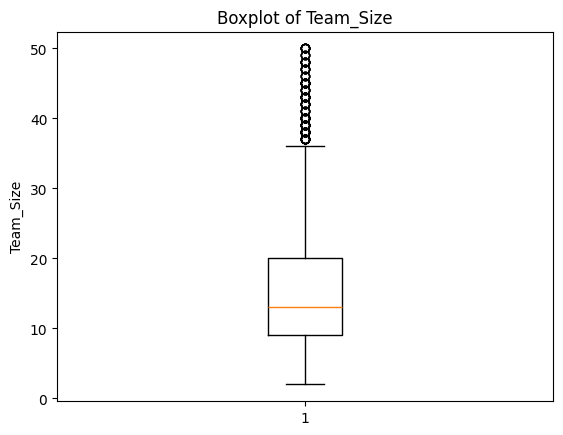

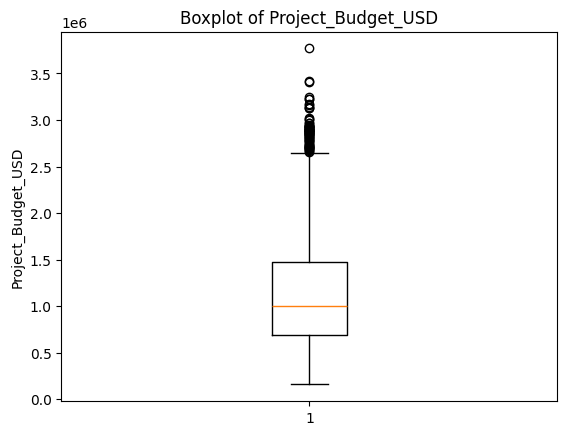

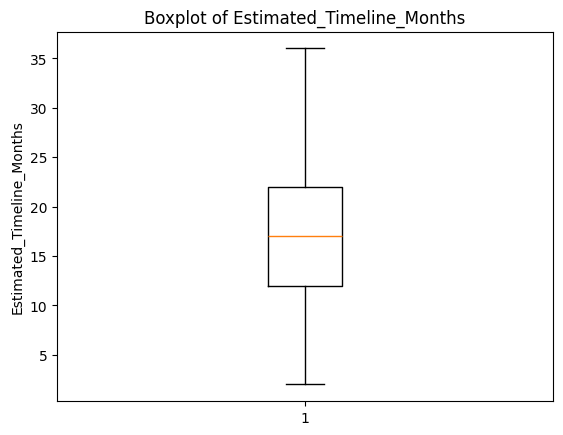

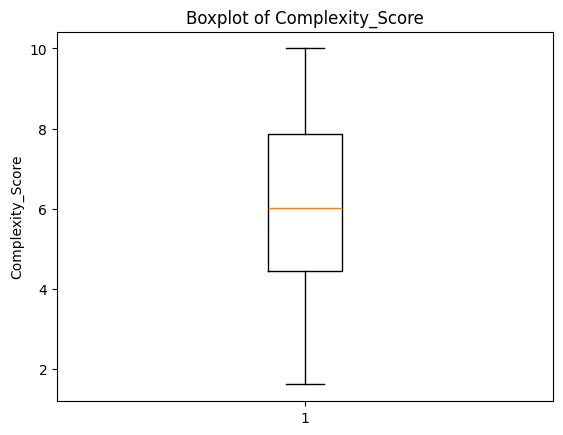

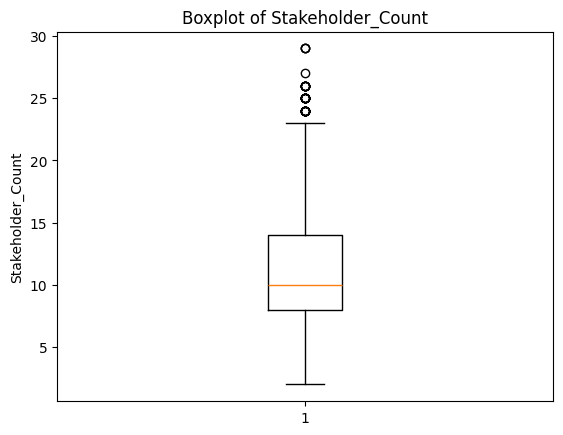

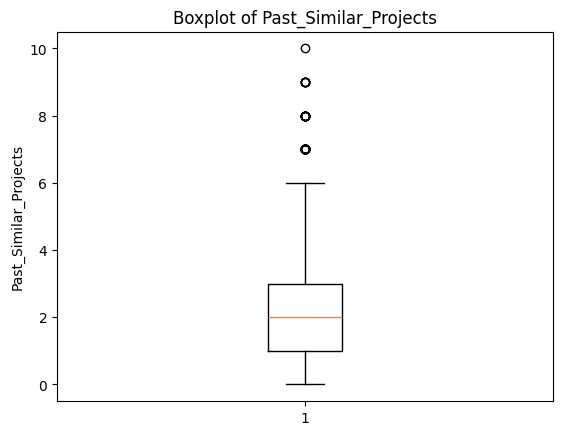

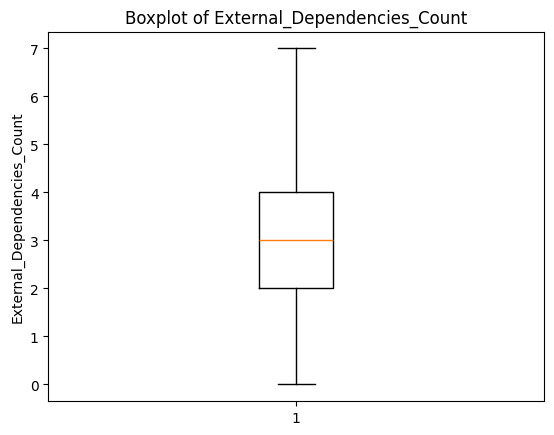

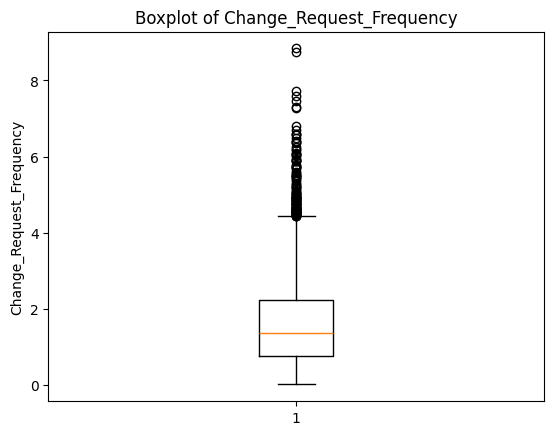

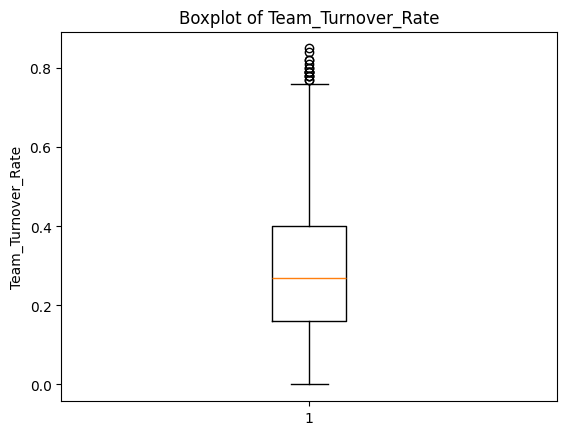

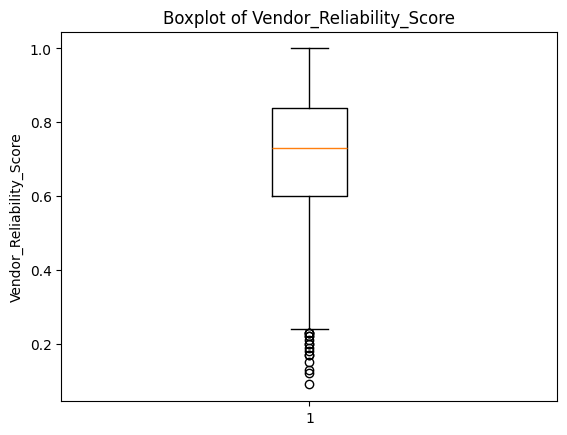

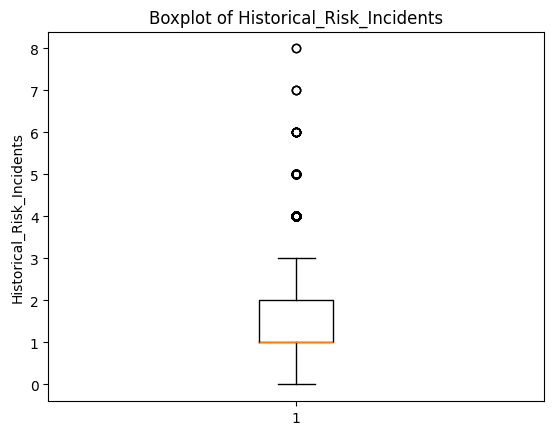

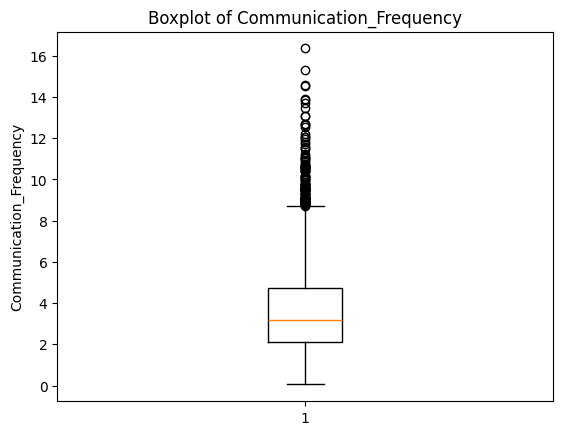

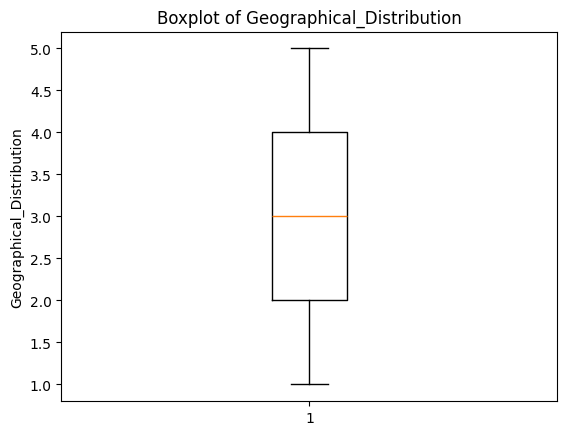

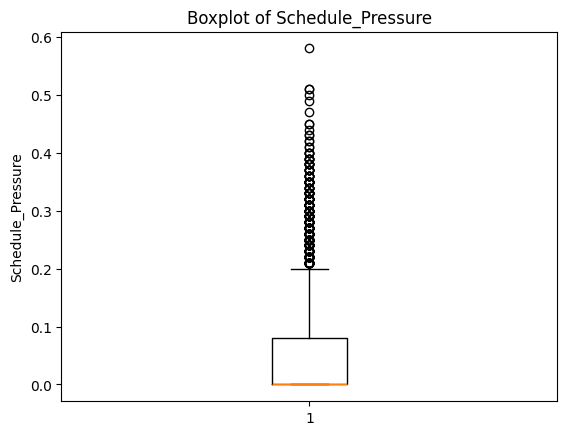

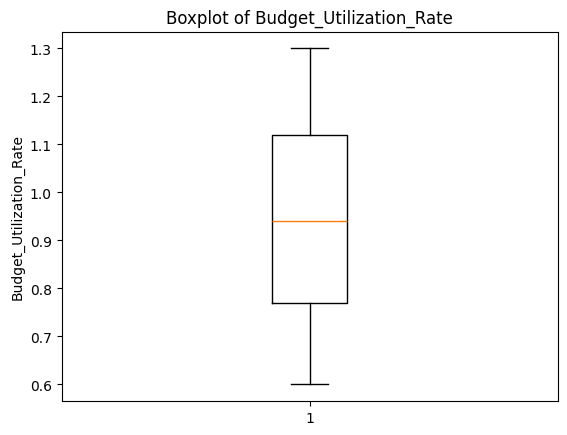

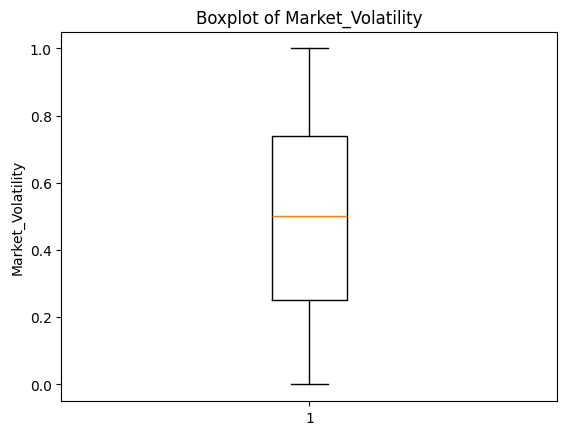

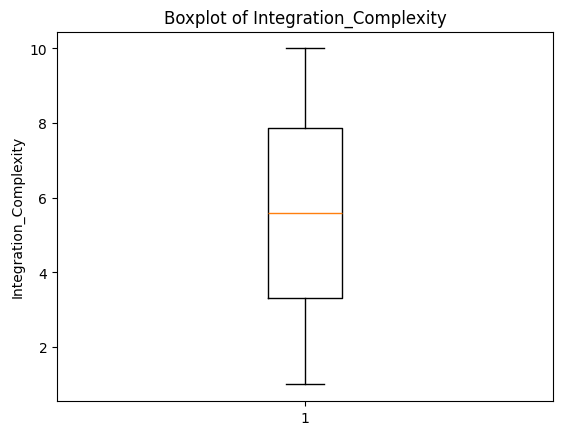

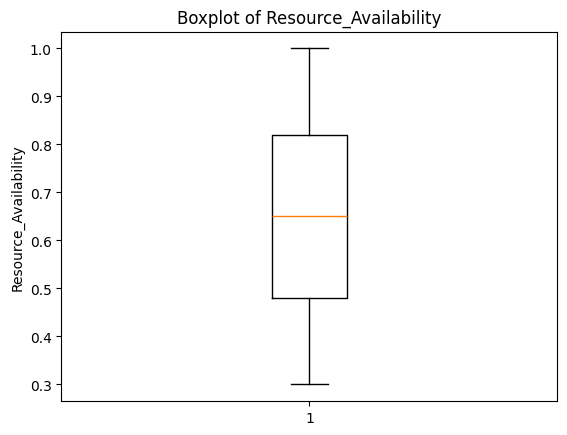

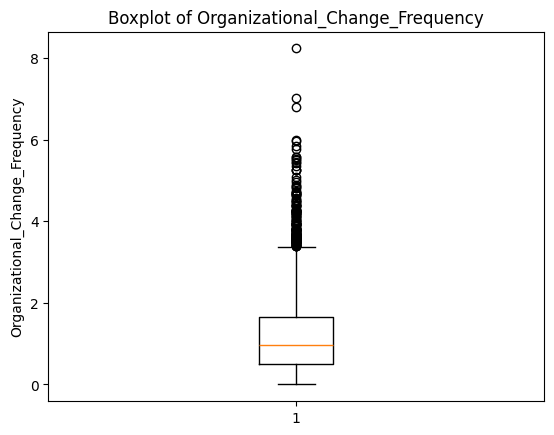

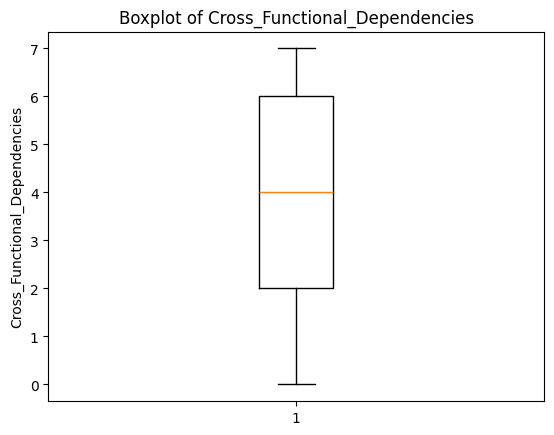

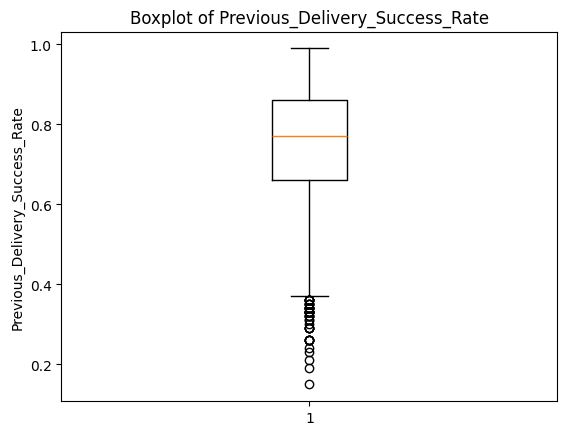

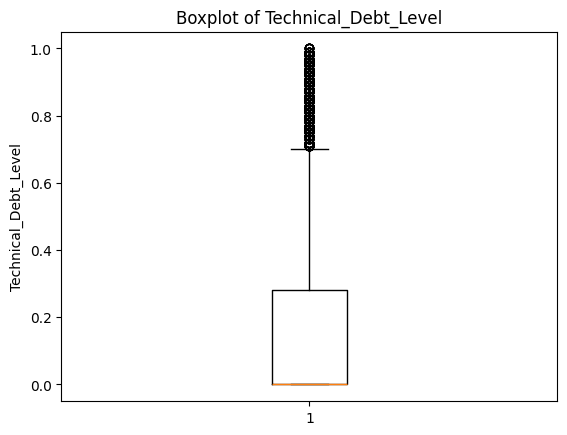

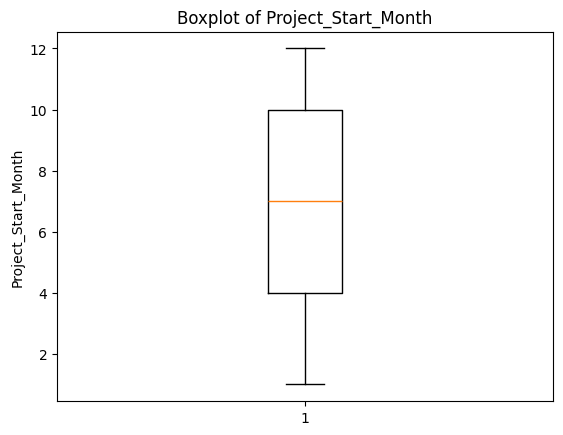

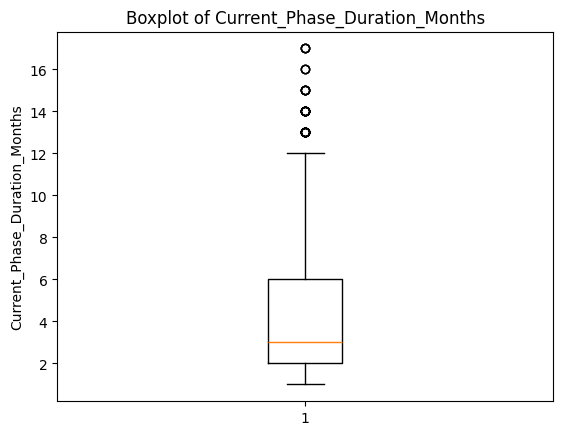

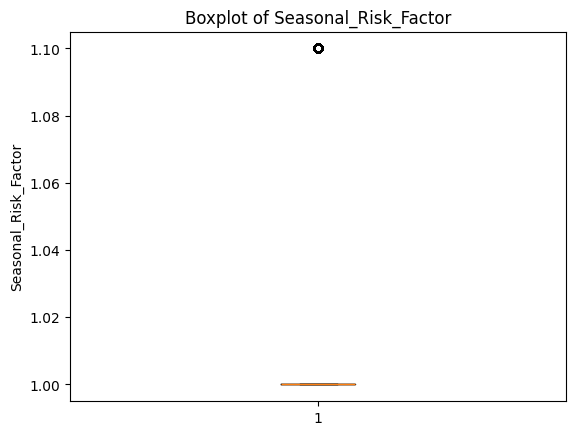

In [10]:
num_features = df.select_dtypes(include=np.number).columns
for col in num_features:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [11]:
int_features = [
    "Team_Size",
    "Estimated_Timeline_Months",
    "Stakeholder_Count",
    "Past_Similar_Projects",
    "Historical_Risk_Incidents",
    "Current_Phase_Duration_Months",
    "Cross_Functional_Dependencies"
]


num_features = df.select_dtypes(include=np.number).columns
cont_features = [col for col in num_features if col not in int_features]
def get_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return lower, upper
for col in int_features:
    lower, upper = get_outlier_bounds(df[col])

    mode_value = df[col].mode()[0]

    df.loc[(df[col] < lower) | (df[col] > upper), col] = mode_value
for col in cont_features:
    lower, upper = get_outlier_bounds(df[col])

    median_value = df[col].median()

    df.loc[(df[col] < lower) | (df[col] > upper), col] = median_value


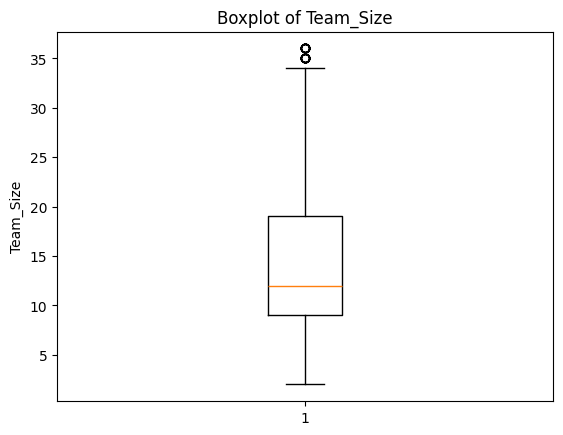

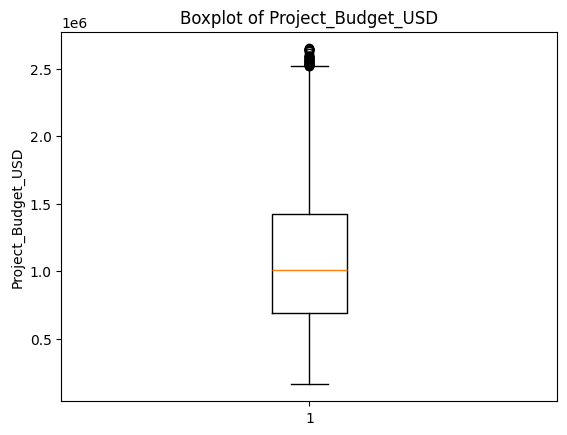

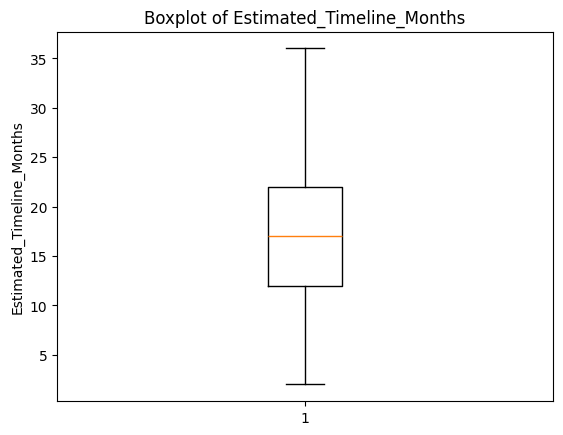

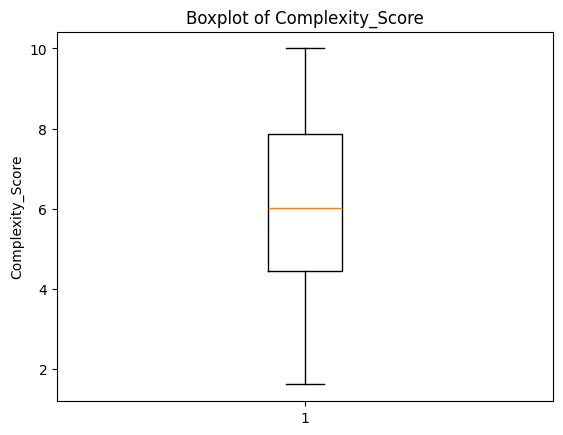

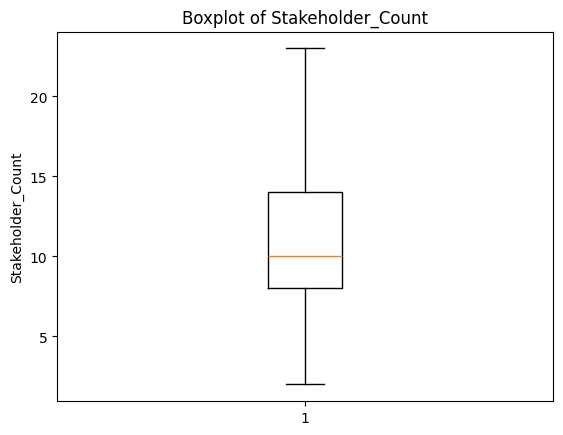

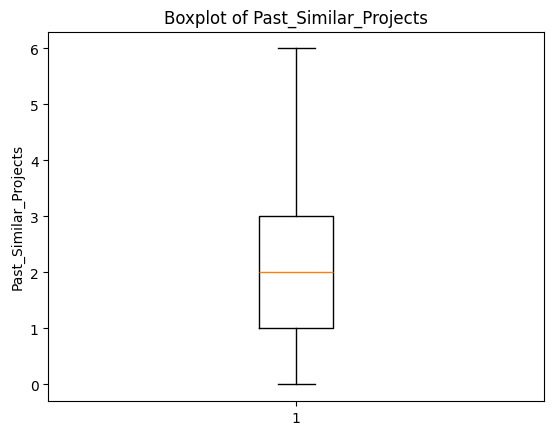

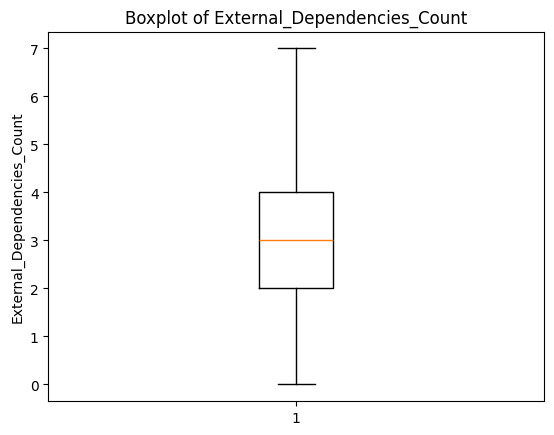

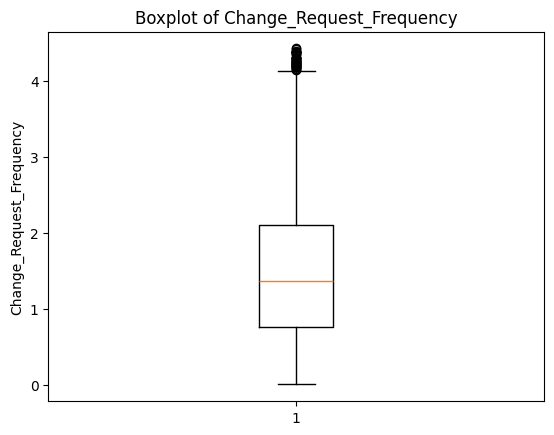

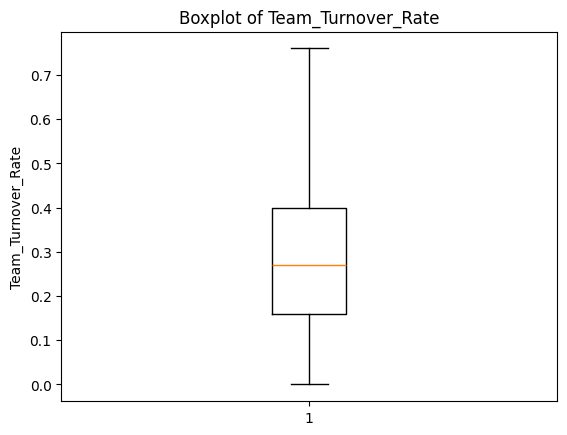

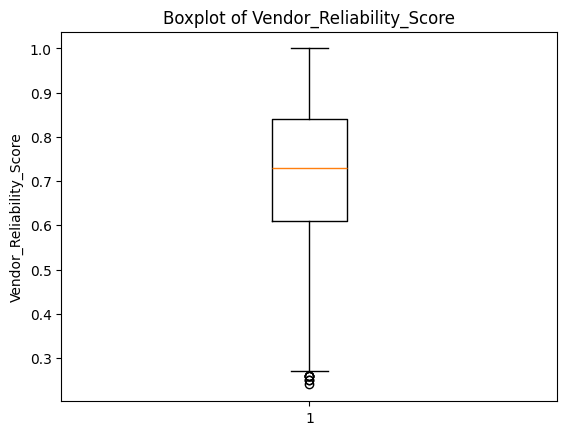

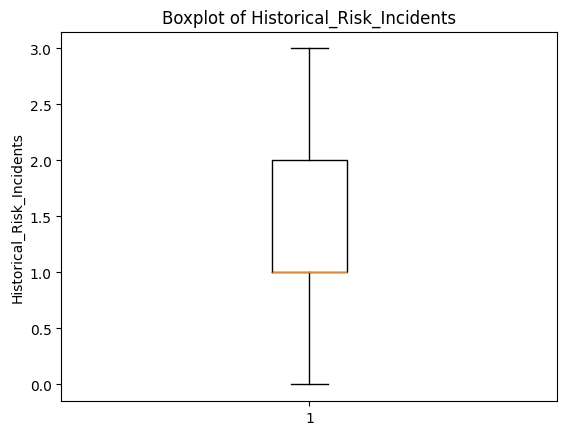

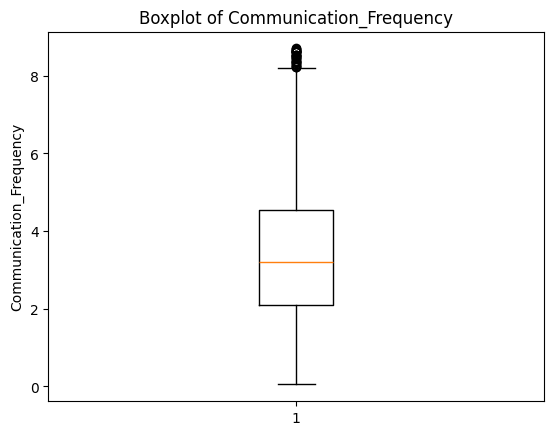

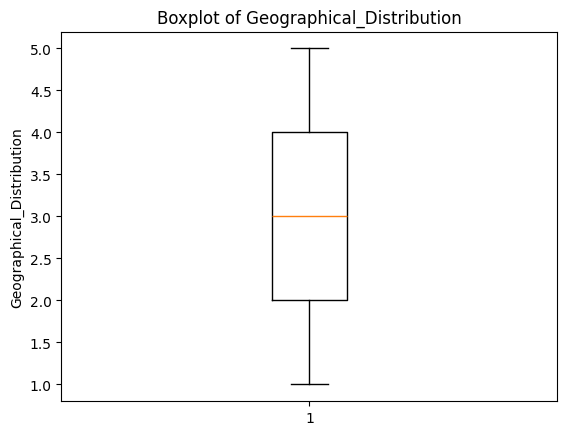

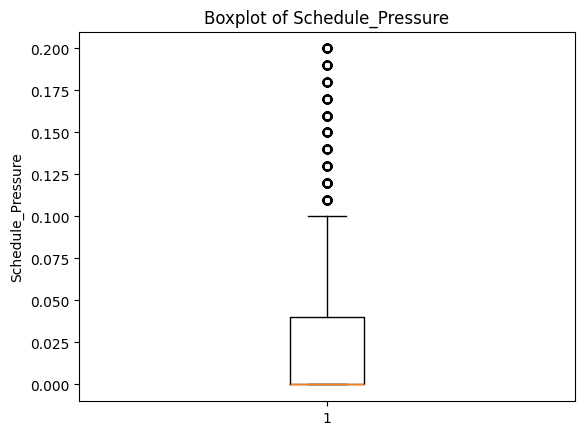

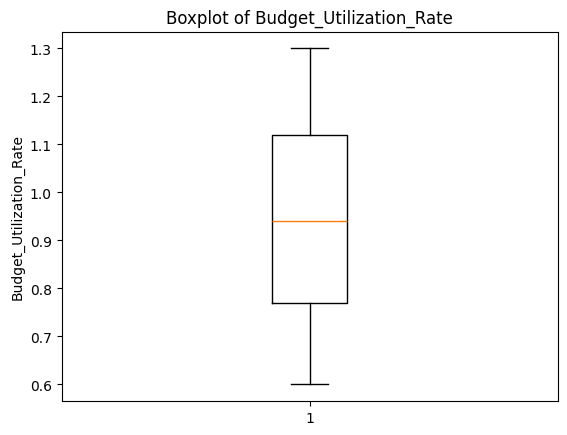

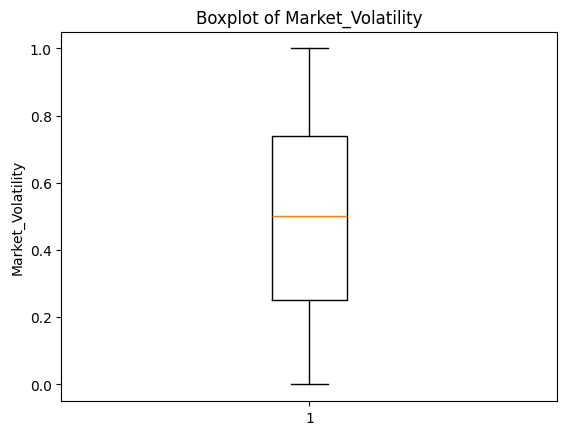

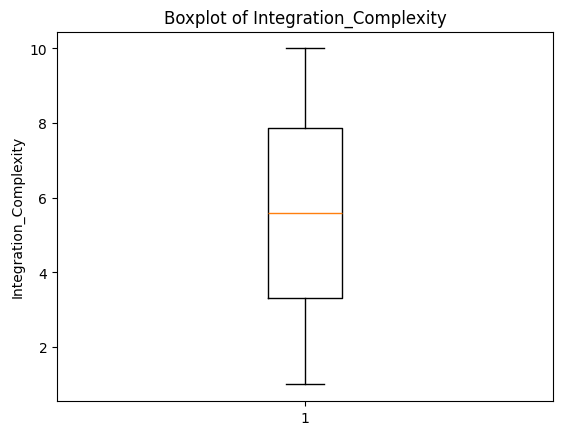

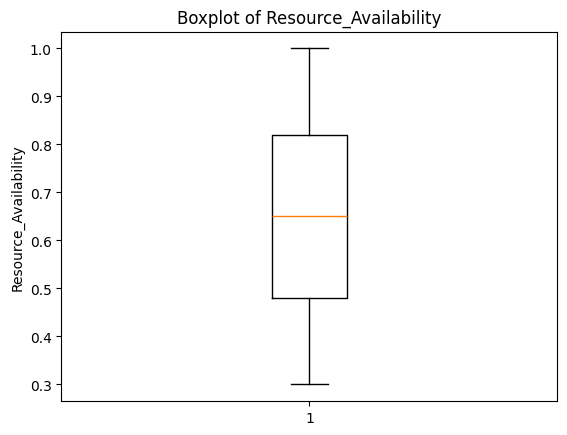

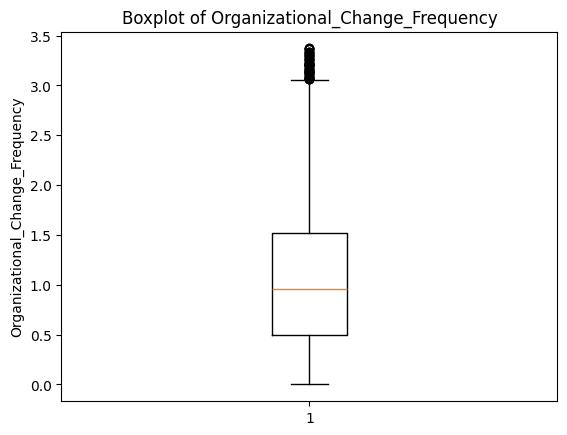

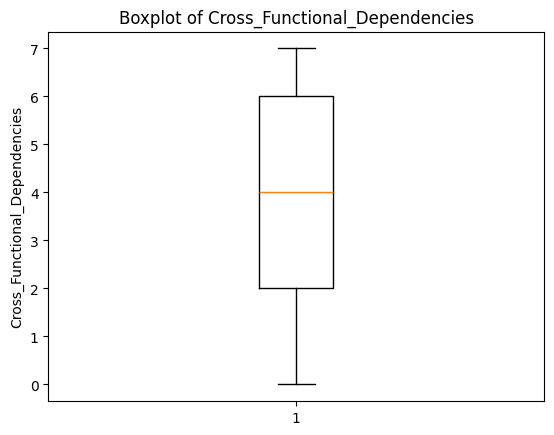

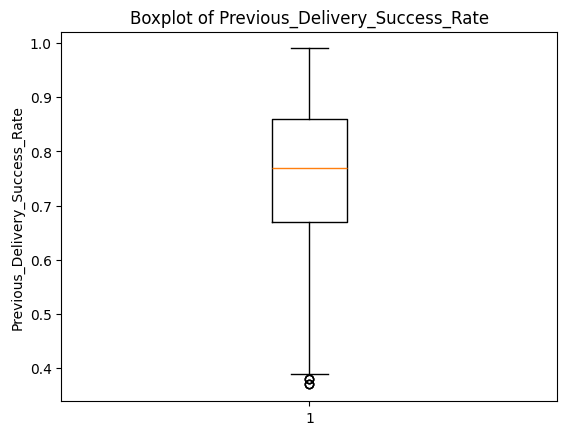

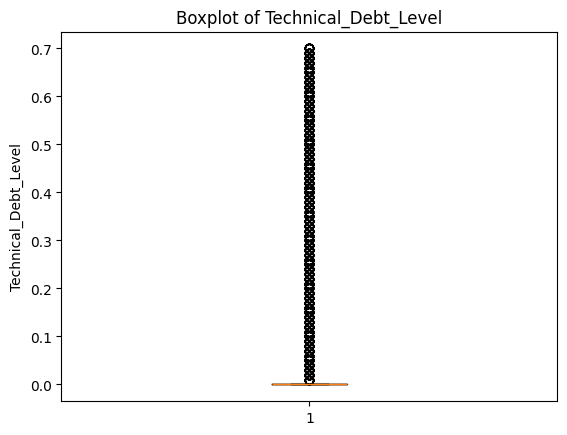

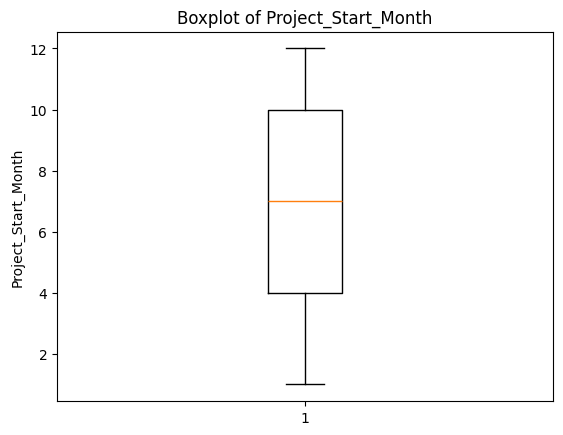

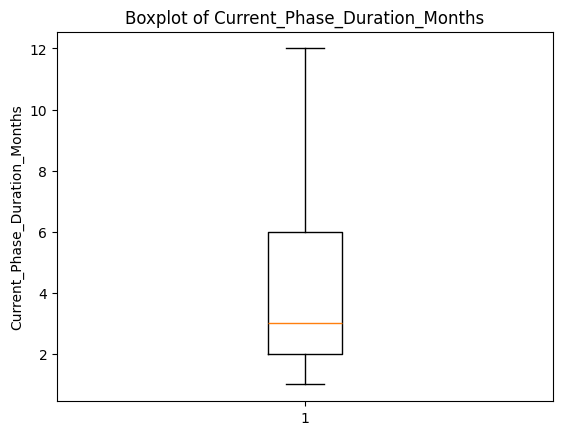

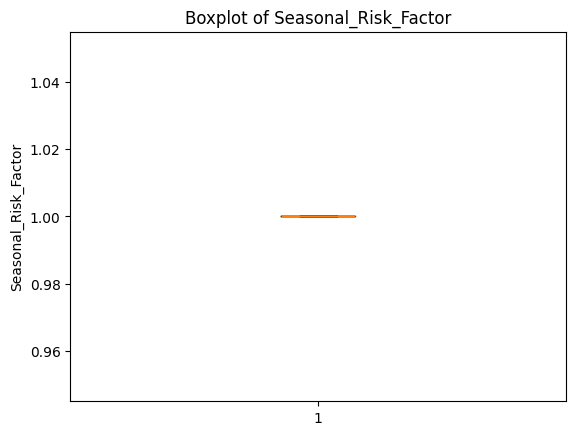

In [12]:
num_features = df.select_dtypes(include=np.number).columns
for col in num_features:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [13]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Project_Type', 'Methodology_Used', 'Team_Experience_Level',
       'Project_Phase', 'Requirement_Stability', 'Regulatory_Compliance_Level',
       'Technology_Familiarity', 'Stakeholder_Engagement_Level',
       'Executive_Sponsorship', 'Funding_Source', 'Priority_Level',
       'Project_Manager_Experience', 'Org_Process_Maturity',
       'Data_Security_Requirements', 'Key_Stakeholder_Availability',
       'Contract_Type', 'Resource_Contention_Level', 'Industry_Volatility',
       'Client_Experience_Level', 'Change_Control_Maturity',
       'Risk_Management_Maturity', 'Team_Colocation', 'Documentation_Quality',
       'Risk_Level'],
      dtype='object')


In [14]:
one_hot_encoding=['Project_Type','Methodology_Used','Funding_Source','Org_Process_Maturity','Contract_Type']
df = pd.get_dummies(df, columns=one_hot_encoding, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [15]:
df['Risk_Level'].unique()

array(['High', 'Low', 'Medium', 'Critical'], dtype=object)

In [16]:
ordinal_cols = ['Team_Experience_Level', 'Project_Phase', 'Requirement_Stability',
       'Regulatory_Compliance_Level', 'Technology_Familiarity',
       'Stakeholder_Engagement_Level', 'Executive_Sponsorship', 'Priority_Level',
        'Project_Manager_Experience',
        'Data_Security_Requirements',
       'Key_Stakeholder_Availability',
       'Resource_Contention_Level', 'Industry_Volatility',
       'Client_Experience_Level', 'Change_Control_Maturity',
       'Risk_Management_Maturity', 'Team_Colocation', 'Documentation_Quality',
       'Risk_Level']

categories = [
    [ 'Junior','Mixed', 'Senior', 'Expert'],
    ['Initiation', 'Planning', 'Execution', 'Monitoring', 'Closure'],
    [ 'Volatile','Moderate', 'Stable'],
    ["Low", "Medium", "High","Critical"],
    ['New','Familiar','Expert'],
    ['Poor','Low', 'Medium',  'High','Excellent'],
    ['Weak','Moderate',  'Strong'],
    ["Low", "Medium", "High","Critical"],
    ['Junior PM','Mid-level PM',  'Senior PM' ,'Certified PM'],
    ["Low", "Medium", "High",'Strict'],
    ['Poor','Limited','Good' , 'Moderate','Excellent' ],
    ["Low", "Medium", "High"],
    ['Stable', 'Moderate', 'High', 'Extreme'],
    ['First-time', 'Occasional', 'Regular', 'Strategic'],
    ['Basic', 'Formal', 'Advanced'],
    ['Basic', 'Formal', 'Advanced'],
    ['Fully Colocated', 'Partially Colocated', 'Hybrid', 'Fully Remote'],
    ['Poor','Good',  'Basic', 'Excellent'],
    ["Low", "Medium", "High","Critical"]

]

encoder = OrdinalEncoder(categories=categories)

df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Team_Size                        4000 non-null   int64  
 1   Project_Budget_USD               4000 non-null   float64
 2   Estimated_Timeline_Months        4000 non-null   int64  
 3   Complexity_Score                 4000 non-null   float64
 4   Stakeholder_Count                4000 non-null   int64  
 5   Team_Experience_Level            4000 non-null   float64
 6   Past_Similar_Projects            4000 non-null   int64  
 7   External_Dependencies_Count      4000 non-null   int64  
 8   Change_Request_Frequency         4000 non-null   float64
 9   Project_Phase                    4000 non-null   float64
 10  Requirement_Stability            4000 non-null   float64
 11  Team_Turnover_Rate               4000 non-null   float64
 12  Vendor_Reliability_S

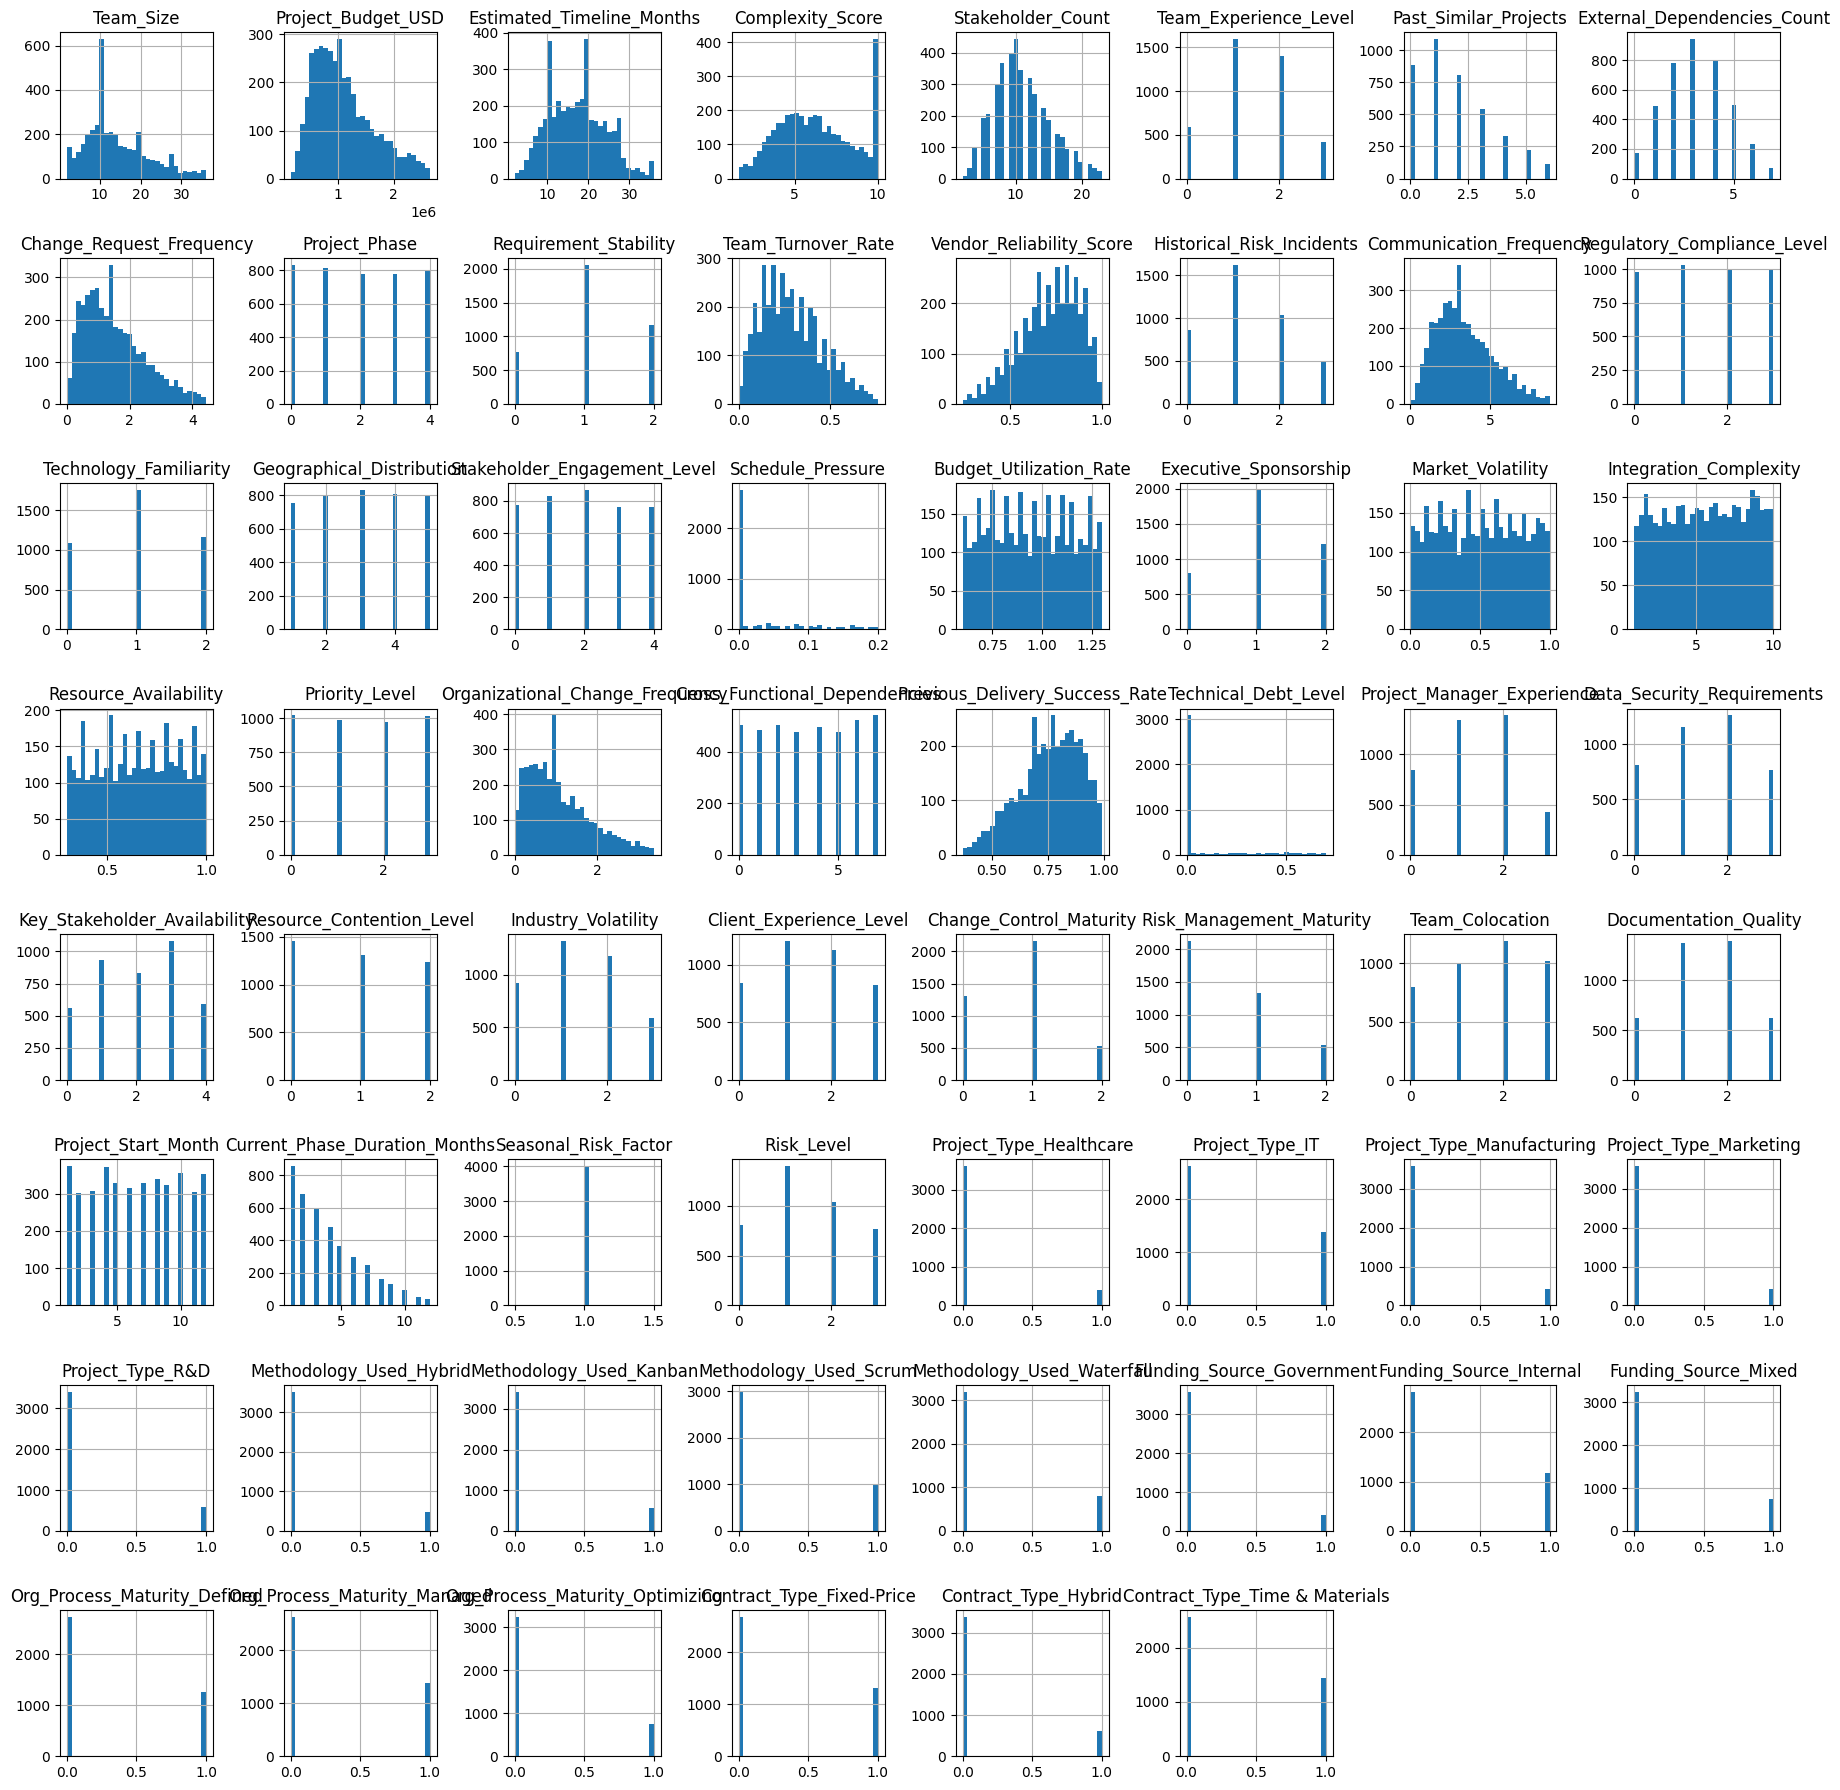

In [18]:
num_cols = df.columns

df[num_cols].hist(bins=30, figsize=(18, 18))
plt.tight_layout()
plt.show()


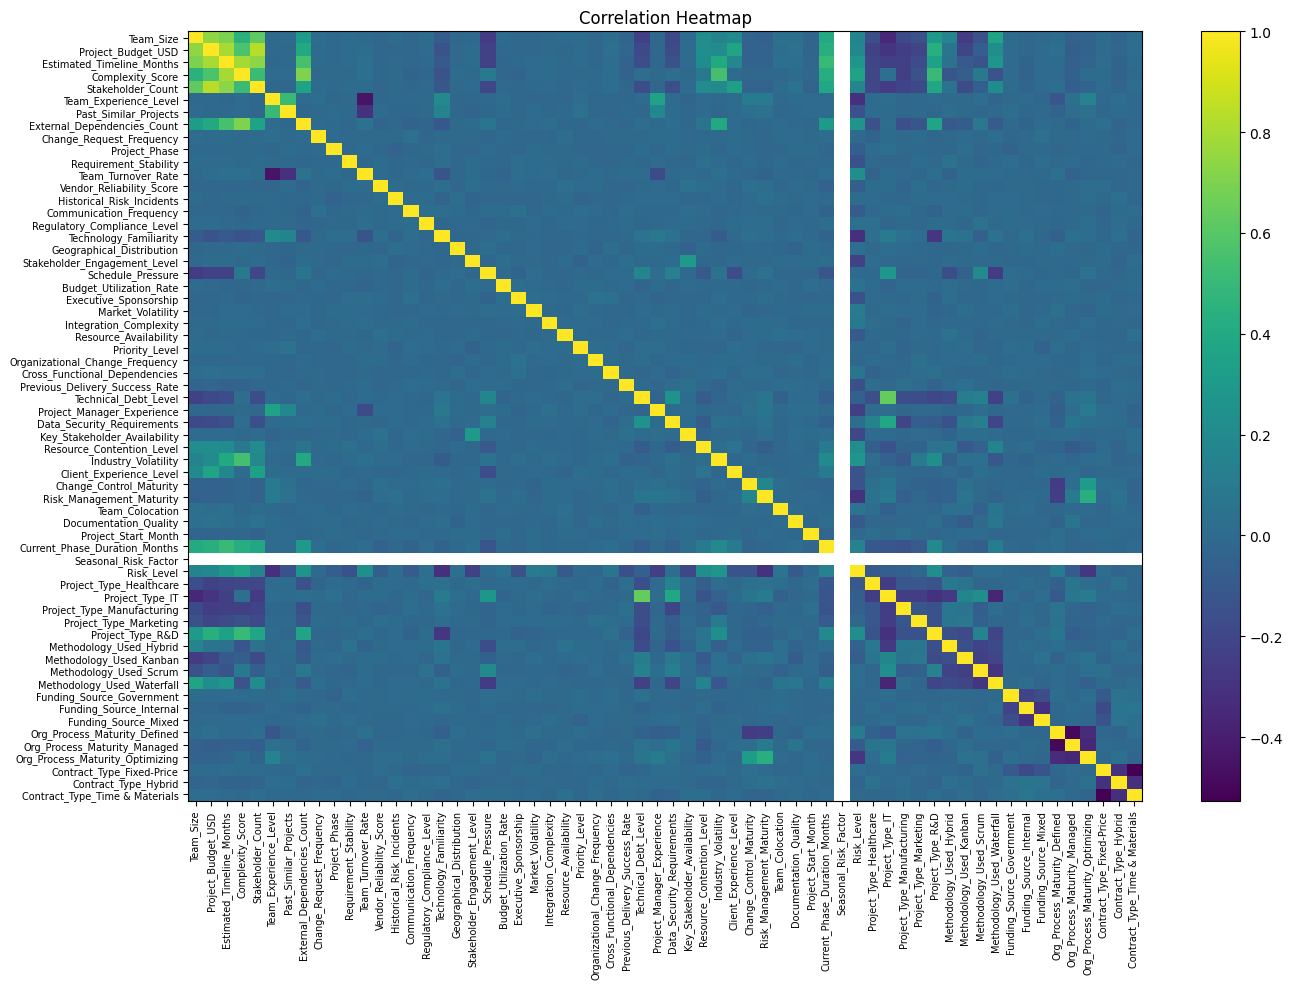

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


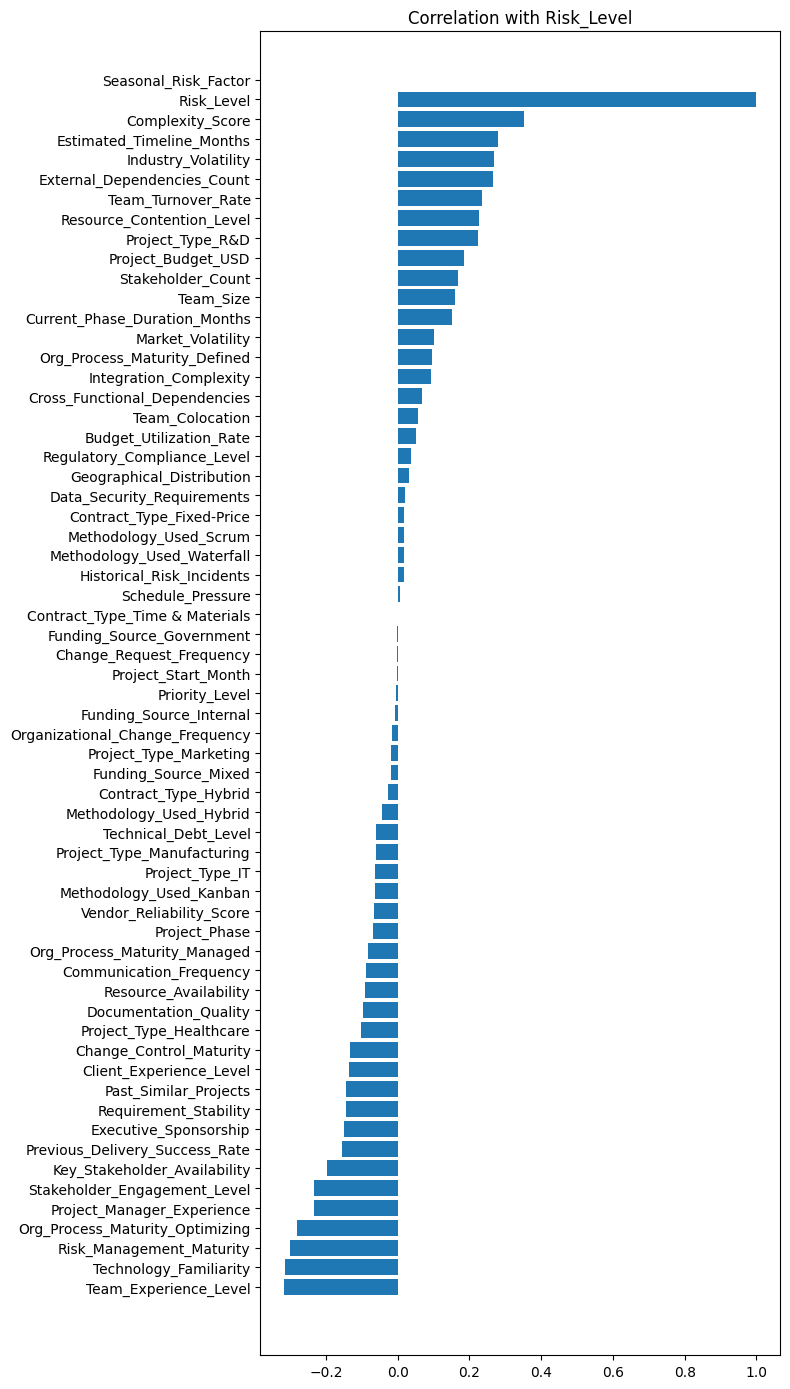

In [20]:
target = "Risk_Level"
corr_target = df.corr(numeric_only=True)[target].sort_values()

plt.figure(figsize=(8, 14))
plt.barh(corr_target.index, corr_target.values)
plt.title(f"Correlation with {target}")
plt.tight_layout()
plt.show()


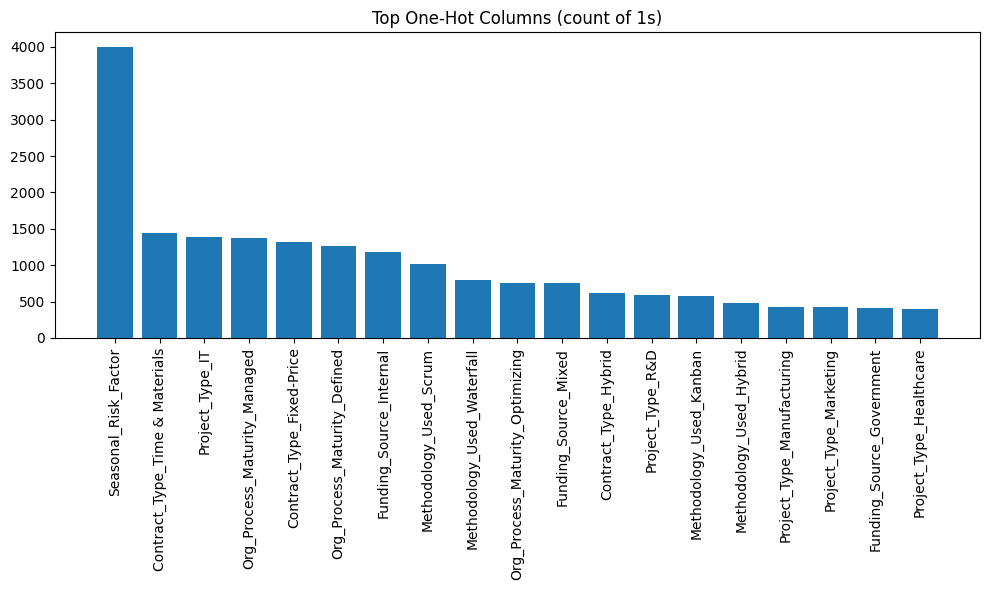

In [21]:
binary_cols = [c for c in df.columns if df[c].dropna().isin([0,1]).all()]
counts = df[binary_cols].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.title("Top One-Hot Columns (count of 1s)")
plt.tight_layout()
plt.show()


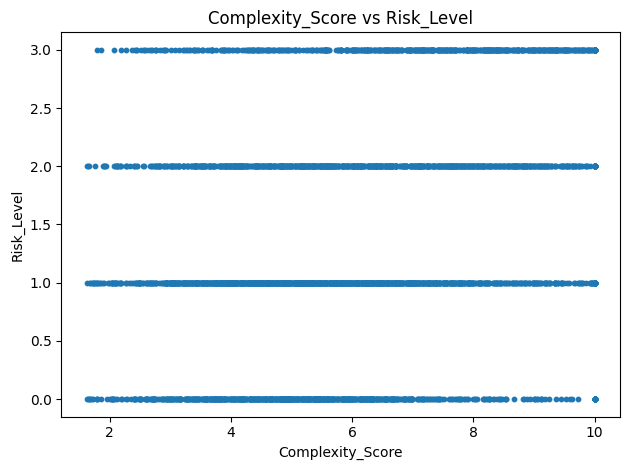

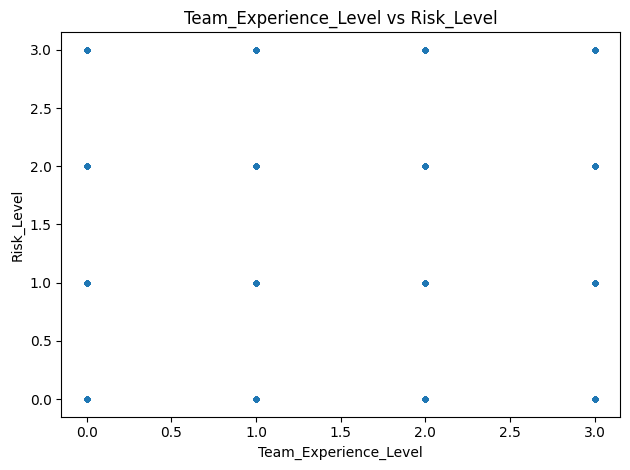

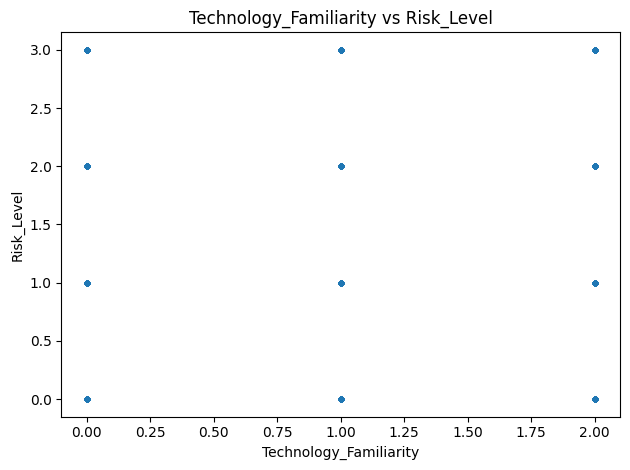

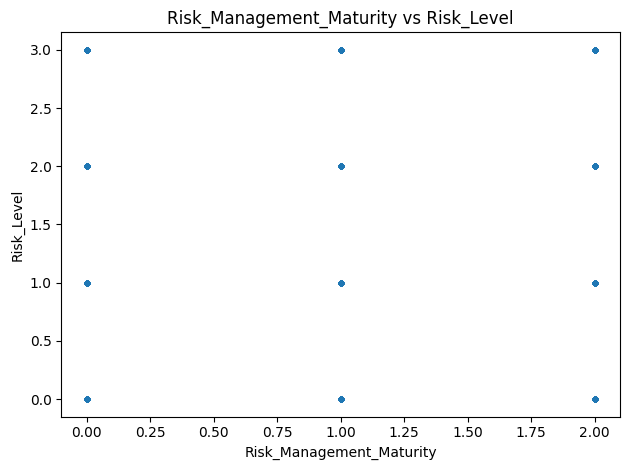

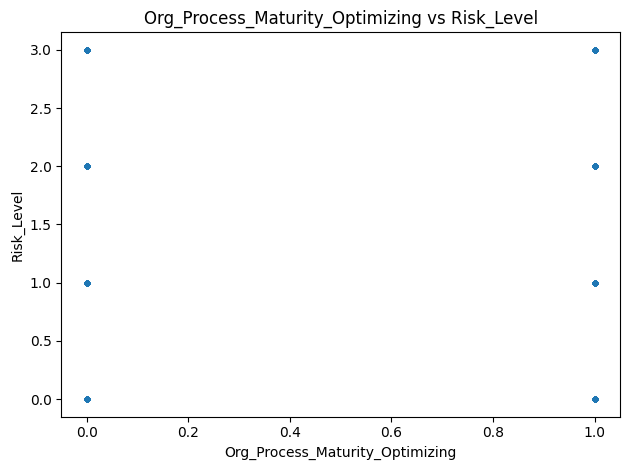

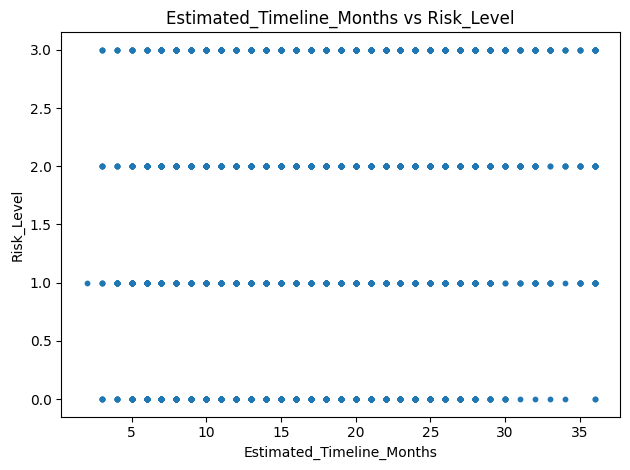

In [22]:
target = "Risk_Level"
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
top_feats = corrs.head(6).index

for col in top_feats:
    plt.figure()
    plt.scatter(df[col], df[target], s=10)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()


In [23]:
import os

folder_path = "saved_test_data"

if not os.path.exists(folder_path):
    os.makedirs(folder_path)


In [24]:
from sklearn.model_selection import train_test_split

target = "Risk_Level"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [25]:
test_df = X_test.copy()
test_df[target] = y_test

test_df.to_csv(os.path.join(folder_path, "test_data.csv"), index=False)


In [26]:
def make_binary_targets(y):
    y1 = (y >= 1).astype(int)
    y2 = (y >= 2).astype(int)
    y3 = (y >= 3).astype(int)
    return y1, y2, y3

y1_train, y2_train, y3_train = make_binary_targets(y_train)


In [27]:
def build_xgb():
    return XGBClassifier(
    n_estimators=1200,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    eval_metric="logloss"
)


m1 = build_xgb()
m2 = build_xgb()
m3 = build_xgb()

m1.fit(X_train, y1_train)
m2.fit(X_train, y2_train)
m3.fit(X_train, y3_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1200, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
def ordinal_predict(models, X):
    m1, m2, m3 = models

    p1 = m1.predict_proba(X)[:, 1]
    p2 = m2.predict_proba(X)[:, 1]
    p3 = m3.predict_proba(X)[:, 1]

    return np.round(p1 + p2 + p3).astype(int)

y_pred = ordinal_predict((m1, m2, m3), X_test)


In [29]:
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.90      0.62      0.74       161
         1.0       0.67      0.78      0.72       279
         2.0       0.57      0.76      0.65       207
         3.0       0.91      0.54      0.68       153

    accuracy                           0.70       800
   macro avg       0.76      0.67      0.70       800
weighted avg       0.74      0.70      0.70       800

Confusion matrix:
 [[100  61   0   0]
 [  9 217  53   0]
 [  2  40 157   8]
 [  0   4  66  83]]


In [30]:
import joblib
import os

save_path = "saved_models"

if not os.path.exists(save_path):
    os.makedirs(save_path)

ordinal_model = {
    "m1": m1,
    "m2": m2,
    "m3": m3,
    "feature_order": X_train.columns.tolist()
}

joblib.dump(ordinal_model, os.path.join(save_path, "ordinal_xgb_model.pkl"))

print("Ordinal model saved as single file successfully.")


Ordinal model saved as single file successfully.
